References:
- https://trinhngocthuyen.com/posts/tech/a-dive-into-hog/
- https://stackoverflow.com/questions/67243124/python-skimage-feature-hog-function-meaning-of-parameter-pixels-per-cell-and-ce
- https://thepythoncode.com/article/hog-feature-extraction-in-python
- https://stackoverflow.com/questions/55466298/pytorch-cant-call-numpy-on-variable-that-requires-grad-use-var-detach-num
- https://stackoverflow.com/questions/75501048/how-to-fix-attributeerror-partially-initialized-module-charset-normalizer-has
- https://www.tutorialspoint.com/how-to-move-a-torch-tensor-from-cpu-to-gpu-and-vice-versa
- https://saturncloud.io/blog/how-to-convert-pytorch-tensor-to-numpy-array-using-cuda/
- https://stackoverflow.com/questions/69007342/disable-grad-and-backward-globally
- https://stackoverflow.com/questions/53900910/typeerror-can-t-convert-cuda-tensor-to-numpy-use-tensor-cpu-to-copy-the-tens

In [2]:
%%capture
# %pip install torch torchvision torchaudio
%pip install scipy
%pip install numpy
%pip install pandas
%pip install opencv-python
%pip install matplotlib
%pip install scikit-image
%pip install chardet

In [32]:
from pathlib import Path
from PIL import Image
from scipy.stats import skew
import cv2
import math
import numpy as np
import pandas as pd
import pickle
import PIL
import scipy
import torch
import torchvision
import sys

### Load Database

In [3]:
%%cellEnabled = 0 # Skip cell because one line created code first then modied it into functions 
db = torchvision.datasets.Caltech101("./Databases",  download=True)
print(type(db))
db
image = db[0][0].resize((300,100))
display(image)

data_dict = {}
data_dict["Image"] = image
data_dict["Index"] = 0

UsageError: Cell magic `%%cellEnabled` not found.


### Color Moments

In [4]:
# All code generated by a version of ChaptGPT with some personal modifications as I couldn't find packages/pretrianed models & for reference only

def colorMoments(image):
    # Convert image to PyTorch tensor
    image_tensor = torch.from_numpy(np.array(image))
    # Partition the image into 10x10 grid
    grid = image_tensor.unfold(0, 10, 10).unfold(1, 10, 10)

    # Initialize feature descriptor
    descriptor = torch.empty((10, 10, 3, 3))
    # print(len(grid), len(grid[0]), len(grid[0][0]))
    # Compute color moments for each grid cell
    for i in range(10):
        for j in range(10):
            for k in range(3):
                cell = grid[i, j, :, k].float()
                descriptor[i, j, k, 0] = torch.mean(cell) # Mean
                descriptor[i, j, k, 1] = torch.std(cell) # Standard deviation
                descriptor[i, j, k, 2] = skew(cell.flatten()) # Skewness

    # Reshape to obtain a unified 900 dimensional feature descriptor
    # print(len(descriptor.view(-1)))
    return descriptor.view(-1).cpu().numpy()



### HOG

In [5]:
# All code generated by a version of ChatGPT with some personal modifications as I couldn't find packages/pretrianed models & for reference only


def hog(image_gray):
    # Convert image to PyTorch tensor
    image_tensor = torch.from_numpy(np.array(image_gray)).float()

    # Define Sobel filters
    sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]).float()
    sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]]).float()

    # Compute gradients
    gradient_x = torch.nn.functional.conv2d(image_tensor.unsqueeze(0).unsqueeze(0), sobel_x.unsqueeze(0).unsqueeze(0), padding=1)
    gradient_y = torch.nn.functional.conv2d(image_tensor.unsqueeze(0).unsqueeze(0), sobel_y.unsqueeze(0).unsqueeze(0), padding=1)

    # Compute gradient magnitude and orientation
    magnitude = torch.sqrt(gradient_x**2 + gradient_y**2)
    orientation = torch.atan2(gradient_y, gradient_x)

    # Initialize feature descriptor
    descriptor = torch.empty((10, 10, 9)).to(device)

    # Compute histogram for each grid cell
    for i in range(10):
        for j in range(10):
            cell_magnitude = magnitude[0, i*30:(i+1)*30, j*10:(j+1)*10]
            cell_orientation = orientation[0, i*30:(i+1)*30, j*10:(j+1)*10]
            # Map orientation to bin
            bin = torch.floor(cell_orientation / (np.pi/9)).long() % 9
            # Compute histogram
            descriptor[i, j] = torch.bincount(bin.view(-1), weights=cell_magnitude.view(-1), minlength=9)

    # print("HOG Dimensions")
    # print(len(descriptor), len(descriptor[0]), len(descriptor[0][0]))
    return descriptor.cpu().numpy()



### Resnet

In [6]:
%%cellEnabled = 0 # Skip cell because one line created code first then modied it into functions 

# All code generated by a version of ChatGPT with some personal modifications as I couldn't find packages/pretrianed models & for reference only
# Load image
image = image

# Define transform
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((224, 224)),
    torchvision.transforms.ToTensor(),
    # torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Apply transform to image
image_tensor = transform(image).unsqueeze(0)

# Check if CUDA is available and if so, use GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", str(device))
image_tensor = image_tensor.to(device)

# Load pre-trained ResNet50 model
model = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.DEFAULT)
model.zero_grad(set_to_none=True)
model = model.to(device)
model.eval()
print("Model Loaded")

UsageError: Cell magic `%%cellEnabled` not found.


In [7]:
# All code generated by a version of ChatGPT with some personal modifications as I couldn't find packages/pretrianed models & for reference only

def resNetAvgPool(model, image_tensor):
    # Define hook for avgpool layer
    def hook(module, input, output):
        global avgpool_output
        avgpool_output = output.view(output.size(0), -1)

    handle = model.avgpool.register_forward_hook(hook)

    # Forward pass image through model
    output = model(image_tensor)

    # Remove hook
    handle.remove()

    # Reduce dimensionality of avgpool output by averaging two consecutive entries
    avgpool_output_reduced = (avgpool_output[:, ::2] + avgpool_output[:, 1::2]) / 2

    # print("ResNet AvgPool - Dimensions")
    # print(avgpool_output_reduced.shape)  # Should be [1, 1024]

    return avgpool_output_reduced.cpu().numpy()

In [8]:
# All code generated by a version of ChatGPT with some personal modifications as I couldn't find packages/pretrianed models & for reference only

def resNetlayer3(model, image_tensor):
    # Define hook for layer3
    def hook(module, input, output):
        global layer3_output
        layer3_output = output

    handle = model.layer3.register_forward_hook(hook)

    # Forward pass image through model
    output = model(image_tensor)

    # Remove hook
    handle.remove()

    # Convert tensor to vector by averaging each 14x14 slice
    layer3_output_vector = layer3_output.mean([2, 3])

    # print("ResNet Layer3 - Dimensions")
    # print(layer3_output_vector.shape)  # Should be [1, 1024]

    return layer3_output_vector.cpu().numpy()


In [9]:
# All code generated by a version of ChatGPT with some personal modifications as I couldn't find packages/pretrianed models & for reference only

def resNetFc(model, image_tensor):
    # Define hook for fc layer
    def hook(module, input, output):
        global fc_output
        fc_output = output

    handle = model.fc.register_forward_hook(hook)

    # Forward pass image through model
    output = model(image_tensor)

    # Remove hook
    handle.remove()

    # print("ResNet FC - Dimensions")
    # print(fc_output.shape)  # Should be [1, 1000]

    return fc_output.cpu().numpy()


### Create Database

In [10]:
# For ResNet Model:
# Define transform
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((224, 224)),
    torchvision.transforms.ToTensor(),
    # torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Check if CUDA is available and if so, use GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", str(device))

# Load pre-trained ResNet50 model
model = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.DEFAULT)
torch. set_grad_enabled(False)
model.zero_grad(set_to_none=True)
model = model.to(device)
model.eval()
#=======================================================================================================

db = torchvision.datasets.Caltech101("./Databases",  download=True)
list_dicts = [] 
failed_count = 0
from tqdm import tqdm

for i in tqdm(range(0, len(db))):
    image = db[i][0].resize((300,100))
    data_dict = {}
    data_dict["Image"] = image
    data_dict["Index"] = i
    
    try:    
        data_dict["CM"] = [colorMoments(image)]

        image_gray = image.convert('L')
        data_dict["HOG"] = [hog(image_gray)]

        image_tensor = transform(image).unsqueeze(0)
        image_tensor = image_tensor.to(device)
        data_dict["AvgPool"] = [resNetAvgPool(model, image_tensor)]
        data_dict["Layer3"] = [resNetlayer3(model, image_tensor)]
        data_dict["FC"] = [resNetFc(model, image_tensor)]
    except:
        data_dict["CM"] = []
        data_dict["HOG"] = []
        data_dict["AvgPool"] = []
        data_dict["Layer3"] = []
        data_dict["FC"] = []
        failed_count = failed_count + 1
    
    list_dicts.append(data_dict)

print("Failure Rate: " + str(failed_count) + " / " + str(len(db)))
torch.cuda.empty_cache()

Using Device: cuda
Files already downloaded and verified


  0%|          | 2/8677 [00:02<2:29:17,  1.03s/it]C:\Users\Panik\AppData\Local\Temp\ipykernel_21936\2458175983.py:19: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  descriptor[i, j, k, 2] = skew(cell.flatten()) # Skewness
100%|██████████| 8677/8677 [20:11<00:00,  7.16it/s]

Failure Rate: 381 / 8677


#### Export Results

In [11]:
df = pd.DataFrame()
# with torch.no_grad():
# df = pd.DataFrame(data_dict)
df = pd.DataFrame(list_dicts)

print(len(df))
print(len(df) == len(db))
df.head(5)

df.to_pickle("./Databases/df_db.pickle")


8677
True


#### Display Results

In [4]:
df = pd.read_pickle("./Databases/df_db.pickle")
print(len(df))

8677


In [6]:
imageID = 0

#### Color Moments

8676
0


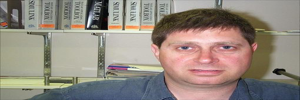

90 635.321


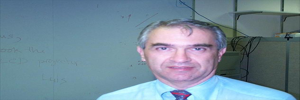

4438 638.286


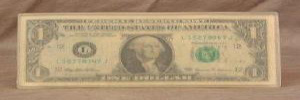

5160 661.164


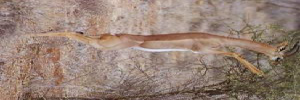

4751 664.382


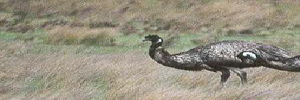

7354 668.187


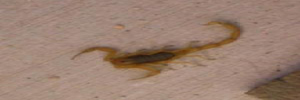

7191 670.957


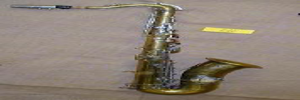

7760 677.561


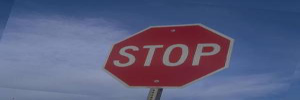

7421 680.924


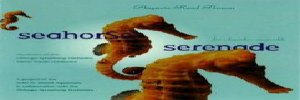

3657 682.851


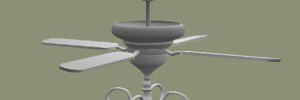

7322 688.407


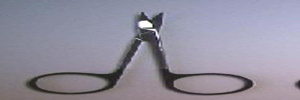

In [55]:
y_df = df[df["Index"] != imageID]
x = df[df["Index"] == imageID]

# x["CM"].values[0][0]

resultList = []
for i, row in y_df.iterrows():
    # if len(row["CM"][0]) > 0:
    try:
        calculation = scipy.spatial.distance.euclidean(x["CM"].values[0][0], row["CM"][0])
    # else:
    except: 
        calculation = sys.float_info.max
    resultList.append([row["Image"], row["Index"], calculation])

print(len(resultList))
sortDF = pd.DataFrame(resultList, columns=["Image", "Index", "Euclidian"])

print(imageID)
display(x["Image"].values[0])
for i in sortDF.sort_values("Euclidian").values[0:10]:
    print(i[1], round(i[2], 3))
    display(i[0])

#### HOG

8676
0


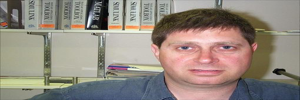

1 1.7976931348623157e+308


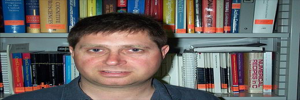

5793 1.7976931348623157e+308


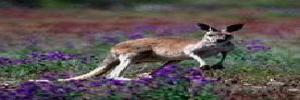

5792 1.7976931348623157e+308


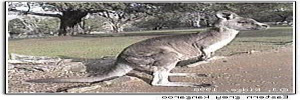

5791 1.7976931348623157e+308


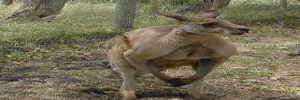

5790 1.7976931348623157e+308


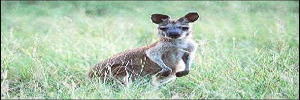

5789 1.7976931348623157e+308


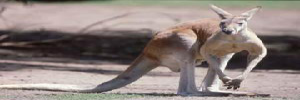

5788 1.7976931348623157e+308


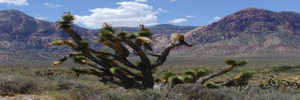

5787 1.7976931348623157e+308


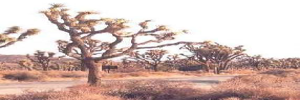

5786 1.7976931348623157e+308


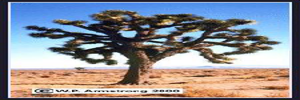

5785 1.7976931348623157e+308


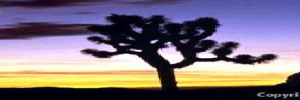

In [56]:
y_df = df[df["Index"] != imageID]
x = df[df["Index"] == imageID]

# x["CM"].values[0][0]

resultList = []
for i, row in y_df.iterrows():
    # if len(row["CM"][0]) > 0:
    try:
        calculation = scipy.spatial.distance.euclidean(x["HOG"].values[0][0], row["HOG"][0])
    # else:
    except: 
        calculation = sys.float_info.max
    resultList.append([row["Image"], row["Index"], calculation])

print(len(resultList))
sortDF = pd.DataFrame(resultList, columns=["Image", "Index", "Euclidian"])

print(imageID)
display(x["Image"].values[0])
for i in sortDF.sort_values("Euclidian").values[0:10]:
    print(i[1], round(i[2], 3))
    display(i[0])

#### AvgPool

8676
0


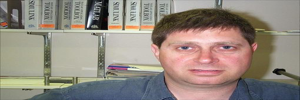

1 1.7976931348623157e+308


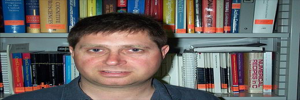

5793 1.7976931348623157e+308


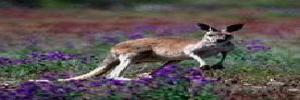

5792 1.7976931348623157e+308


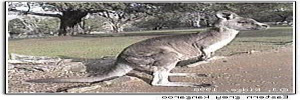

5791 1.7976931348623157e+308


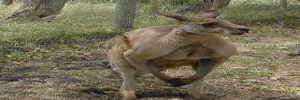

5790 1.7976931348623157e+308


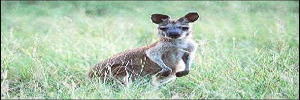

5789 1.7976931348623157e+308


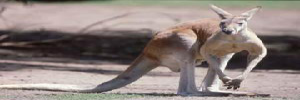

5788 1.7976931348623157e+308


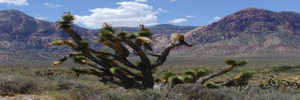

5787 1.7976931348623157e+308


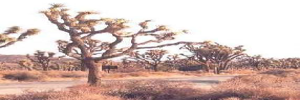

5786 1.7976931348623157e+308


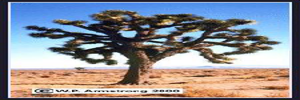

5785 1.7976931348623157e+308


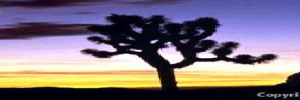

In [57]:
y_df = df[df["Index"] != imageID]
x = df[df["Index"] == imageID]

# x["CM"].values[0][0]

resultList = []
for i, row in y_df.iterrows():
    # if len(row["CM"][0]) > 0:
    try:
        calculation = scipy.spatial.distance.euclidean(x["AvgPool"].values[0][0], row["AvgPool"][0])
    # else:
    except: 
        calculation = sys.float_info.max
    resultList.append([row["Image"], row["Index"], calculation])

print(len(resultList))
sortDF = pd.DataFrame(resultList, columns=["Image", "Index", "Euclidian"])

print(imageID)
display(x["Image"].values[0])
for i in sortDF.sort_values("Euclidian").values[0:10]:
    print(i[1], round(i[2], 3))
    display(i[0])

#### Layer 3

8676
0


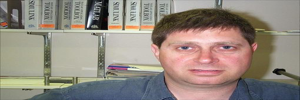

1 1.7976931348623157e+308


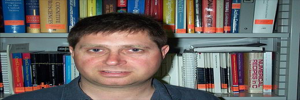

5793 1.7976931348623157e+308


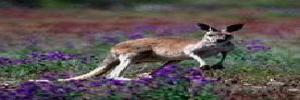

5792 1.7976931348623157e+308


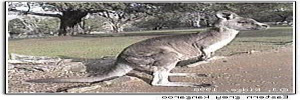

5791 1.7976931348623157e+308


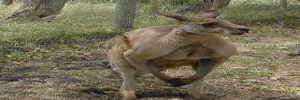

5790 1.7976931348623157e+308


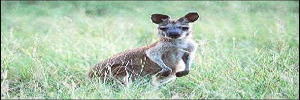

5789 1.7976931348623157e+308


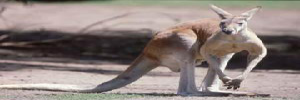

5788 1.7976931348623157e+308


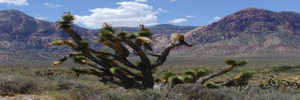

5787 1.7976931348623157e+308


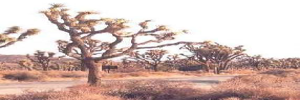

5786 1.7976931348623157e+308


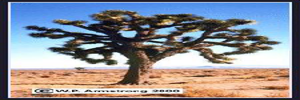

5785 1.7976931348623157e+308


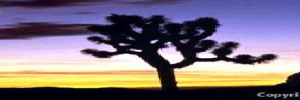

In [58]:
y_df = df[df["Index"] != imageID]
x = df[df["Index"] == imageID]

# x["CM"].values[0][0]

resultList = []
for i, row in y_df.iterrows():
    # if len(row["CM"][0]) > 0:
    try:
        calculation = scipy.spatial.distance.euclidean(x["Layer3"].values[0][0], row["Layer3"][0])
    # else:
    except: 
        calculation = sys.float_info.max
    resultList.append([row["Image"], row["Index"], calculation])

print(len(resultList))
sortDF = pd.DataFrame(resultList, columns=["Image", "Index", "Euclidian"])

print(imageID)
display(x["Image"].values[0])
for i in sortDF.sort_values("Euclidian").values[0:10]:
    print(i[1], round(i[2], 3))
    display(i[0])

#### FC

8676
0


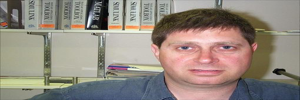

1 1.7976931348623157e+308


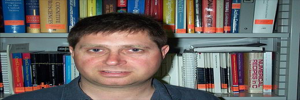

5793 1.7976931348623157e+308


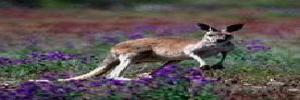

5792 1.7976931348623157e+308


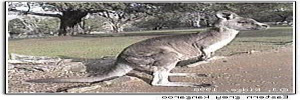

5791 1.7976931348623157e+308


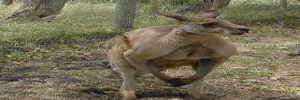

5790 1.7976931348623157e+308


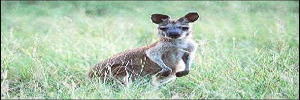

5789 1.7976931348623157e+308


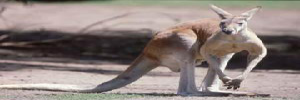

5788 1.7976931348623157e+308


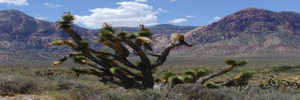

5787 1.7976931348623157e+308


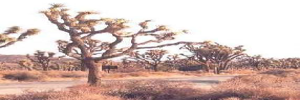

5786 1.7976931348623157e+308


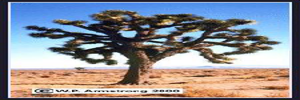

5785 1.7976931348623157e+308


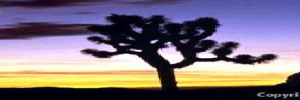

In [59]:
y_df = df[df["Index"] != imageID]
x = df[df["Index"] == imageID]

# x["CM"].values[0][0]

resultList = []
for i, row in y_df.iterrows():
    # if len(row["CM"][0]) > 0:
    try:
        calculation = scipy.spatial.distance.euclidean(x["FC"].values[0][0], row["FC"][0])
    # else:
    except: 
        calculation = sys.float_info.max
    resultList.append([row["Image"], row["Index"], calculation])

print(len(resultList))
sortDF = pd.DataFrame(resultList, columns=["Image", "Index", "Euclidian"])

print(imageID)
display(x["Image"].values[0])
for i in sortDF.sort_values("Euclidian").values[0:10]:
    print(i[1], round(i[2], 3))
    display(i[0])